In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print(df.shape)

df.info()

print(df.isnull().sum())

print(df['label'].value_counts())

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
label      0
message    0
dtype: int64
label
ham     4825
spam     747
Name: count, dtype: int64


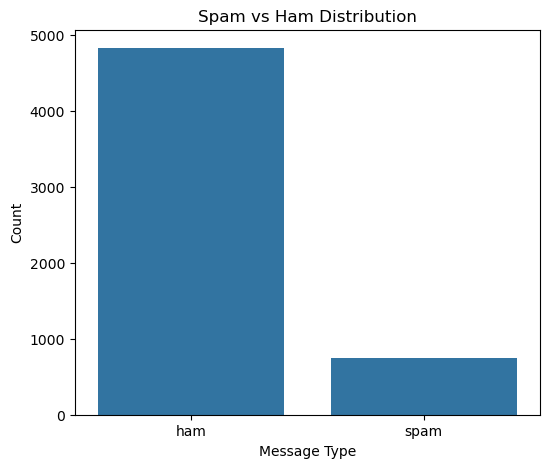

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [12]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [14]:
import nltk
import re
import string

In [17]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jaina\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [22]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jaina\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [24]:
from nltk.tokenize import sent_tokenize

In [26]:

df['char_count'] = df['message'].apply(len)

df['word_count'] = df['message'].apply(
    lambda x: len(x.split())
)
df['sentence_count'] = df['message'].apply(
    lambda x: len(sent_tokenize(x))
)

df.head()

,label,message,label_num,char_count,word_count,sentence_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,2
1,ham,Ok lar... Joking wif u oni...,0,29,6,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,2
3,ham,U dun say so early hor... U c already then say...,0,49,11,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,1


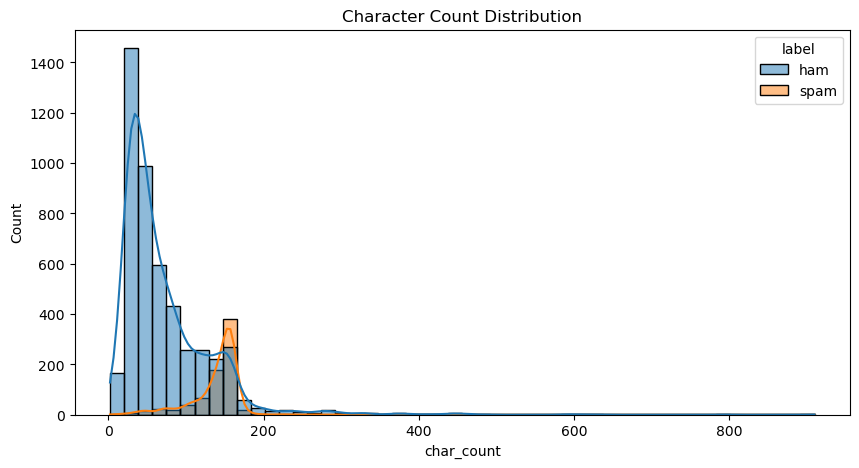

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='char_count',
    hue='label',
    bins=50,
    kde=True
)

plt.title("Character Count Distribution")
plt.show()

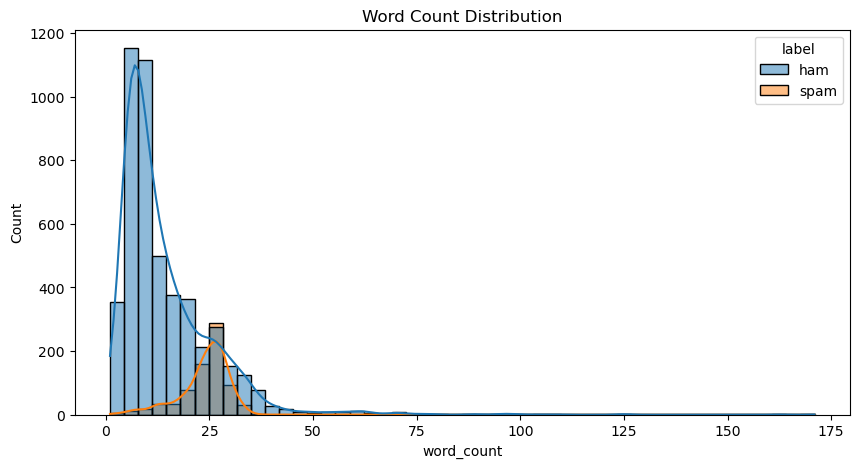

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='word_count',
    hue='label',
    bins=50,
    kde=True
)

plt.title("Word Count Distribution")
plt.show()

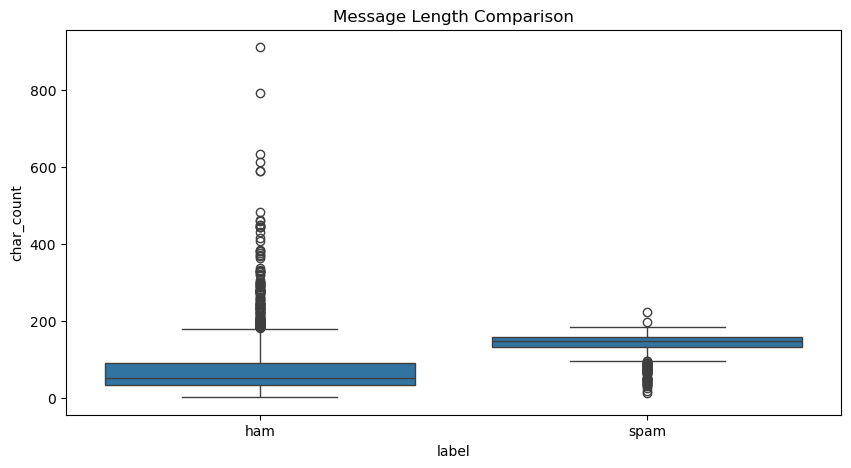

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='label',
    y='char_count',
    data=df
)

plt.title("Message Length Comparison")
plt.show()

In [34]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(
        f"[{string.punctuation}]",
        "",
        text
    )

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stopwords.words('english')
    ]

    # Stemming
    words = [
        ps.stem(word)
        for word in words
    ]

    return " ".join(words)

In [36]:
df['processed_message'] = df['message'].apply(
    preprocess_text
)

df.head()

,label,message,label_num,char_count,word_count,sentence_count,processed_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20,2,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,0,29,6,2,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,0,49,11,1,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13,1,nah dont think goe usf live around though


In [38]:
from wordcloud import WordCloud

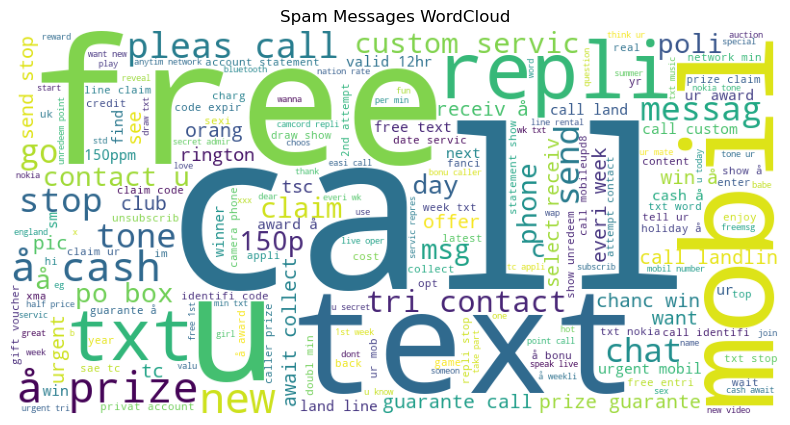

In [40]:
spam_words = " ".join(
    df[df['label']=='spam']
    ['processed_message']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Spam Messages WordCloud")
plt.show()

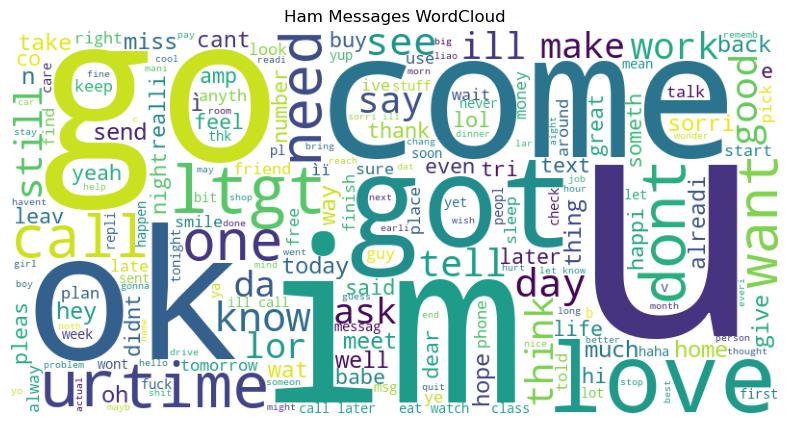

In [42]:
ham_words = " ".join(
    df[df['label']=='ham']
    ['processed_message']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Ham Messages WordCloud")
plt.show()

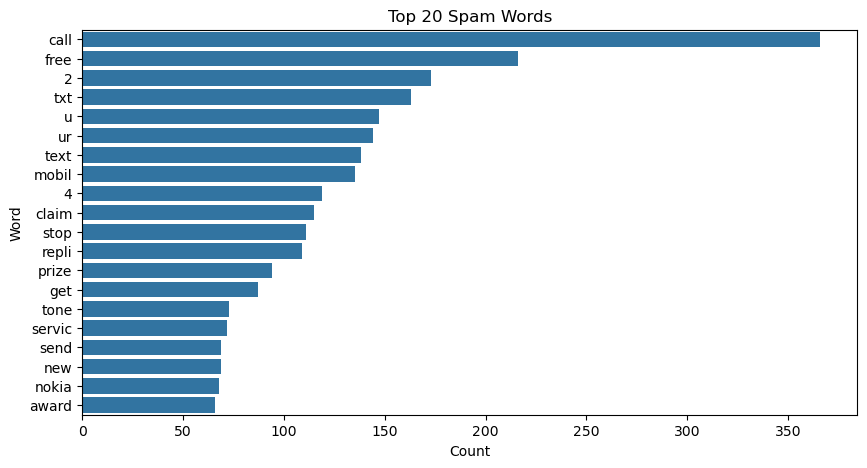

In [44]:
from collections import Counter

spam_corpus = []

for msg in df[df['label']=='spam']['processed_message']:
    spam_corpus.extend(msg.split())

top_words = pd.DataFrame(
    Counter(spam_corpus).most_common(20),
    columns=['Word', 'Count']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Count',
    y='Word',
    data=top_words
)

plt.title("Top 20 Spam Words")
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
X = df['processed_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4457,)
(1115,)


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 5000)
(1115, 5000)


In [56]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [58]:
# Naive Bayes
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train_tfidf, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test_tfidf)

# Probability
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_nb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9650224215246637
ROC AUC: 0.9803069462392485

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



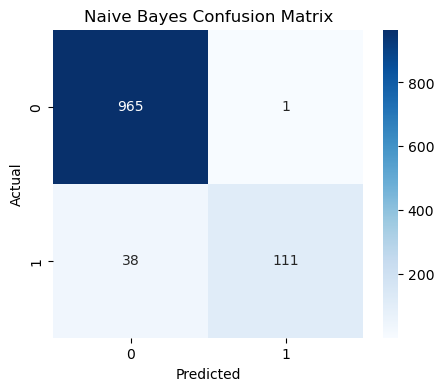

In [60]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9659192825112107
ROC AUC: 0.9825996637347673

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



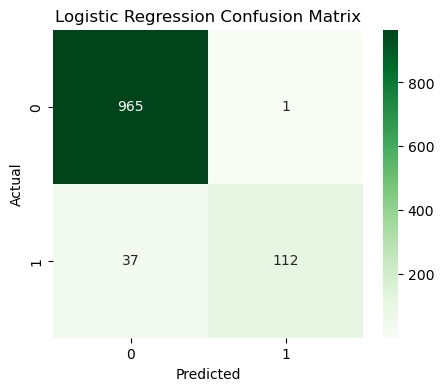

In [64]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [66]:
svm_model = SVC(
    kernel='linear',
    probability=True
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
y_prob_svm = svm_model.predict_proba(X_test_tfidf)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_prob_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9865470852017937
ROC AUC: 0.981918796114886

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



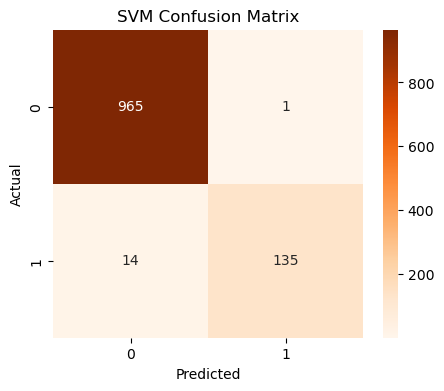

In [68]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

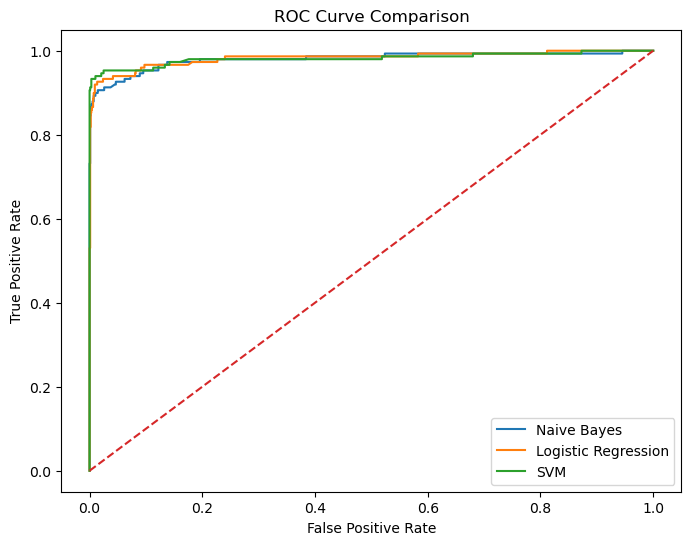

In [70]:
# ROC Curves

fpr_nb, tpr_nb, _ = roc_curve(
    y_test,
    y_prob_nb
)

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    y_prob_svm
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_nb,
    tpr_nb,
    label='Naive Bayes'
)

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label='SVM'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [72]:
def predict_sms(text):

    # preprocess
    processed = preprocess_text(text)

    # vectorize
    vector = tfidf.transform([processed])

    # prediction
    prediction = svm_model.predict(vector)[0]

    # probability
    prob = svm_model.predict_proba(vector)[0][1]

    if prediction == 1:
        print("Spam Message")
    else:
        print("Legitimate Message")

    print("Spam Probability:", round(prob, 3))

In [74]:
predict_sms(
    "Congratulations! You have won a free iPhone. Claim now!"
)

Spam Message
Spam Probability: 1.0


In [76]:
predict_sms(
    "Hey, are we meeting tomorrow for lunch?"
)

Legitimate Message
Spam Probability: 0.0


In [78]:
import pickle

pickle.dump(
    svm_model,
    open('sms_spam_model.pkl', 'wb')
)

pickle.dump(
    tfidf,
    open('tfidf_vectorizer.pkl', 'wb')
)

print("Model Saved Successfully!")

Model Saved Successfully!
